In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
files.upload()

# Load the dataset
df = pd.read_csv('bankmarketing.csv')

# Display the first few rows
df.head()




Saving bankmarketing.csv to bankmarketing.csv


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
#  Check for missing values and data types
df.info()


# Check total missing values per column
df.isnull().sum()

# Check data types only
df.dtypes

# Check missing values percentage per column
(df.isnull().sum() / len(df))* 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,0
age,0.0
job,0.0
marital,0.0
education,0.0
default,0.0
housing,0.0
loan,0.0
contact,0.0
month,0.0
day_of_week,0.0


In [3]:
# 1. Total count of duplicate rows across all columns
df.duplicated().sum()

# 2. Check if any duplicate rows exist (returns True/False)
df.duplicated().any()

# 3. View the duplicate rows (shows occurrences after the first)
df[df.duplicated()]

# 4. View ALL instances of duplicate rows (including the first occurrence)
df[df.duplicated(keep=False)]

# 5. Drop duplicate rows (keep='first' by default)
df_clean = df.drop_duplicates()

In [4]:
# Standard drop list for building a realistic model
df_clean = df_clean.drop(columns=['duration', 'default', 'emp.var.rate', 'nr.employed'])

print(len(df_clean.columns))

17


In [5]:
df_clean.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,y
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
1,57,services,married,high.school,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
2,37,services,married,high.school,yes,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
4,56,services,married,high.school,no,yes,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no


In [6]:
# Summary Statistics
# 1. Numerical columns summary (mean, std, min, max, quantiles)
df_clean.describe()


,age,campaign,pdays,previous,cons.price.idx,cons.conf.idx,euribor3m
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,2.567879,962.464810,0.173013,93.575720,-40.502863,3.621293
std,10.42068,2.770318,186.937102,0.494964,0.578839,4.627860,1.734437
min,17.00000,1.000000,0.000000,0.000000,92.201000,-50.800000,0.634000
25%,32.00000,1.000000,999.000000,0.000000,93.075000,-42.700000,1.344000
50%,38.00000,2.000000,999.000000,0.000000,93.749000,-41.800000,4.857000
75%,47.00000,3.000000,999.000000,0.000000,93.994000,-36.400000,4.961000
max,98.00000,56.000000,999.000000,7.000000,94.767000,-26.900000,5.045000


In [7]:
# 2. Categorical Summary
df_clean.describe(include=['object'])

,job,marital,education,housing,loan,contact,month,day_of_week,poutcome,y
count,41176,41176,41176,41176,41176,41176,41176,41176,41176,41176
unique,12,4,8,3,3,2,10,5,3,2
top,admin.,married,university.degree,yes,no,cellular,may,thu,nonexistent,no
freq,10419,24921,12164,21571,33938,26135,13767,8618,35551,36537


In [8]:
df_clean['age'].describe()

,age
count,41176.00000
mean,40.02380
std,10.42068
min,17.00000
25%,32.00000
50%,38.00000
75%,47.00000
max,98.00000


In [9]:
df_clean['age'].skew()

np.float64(0.7845602604159753)

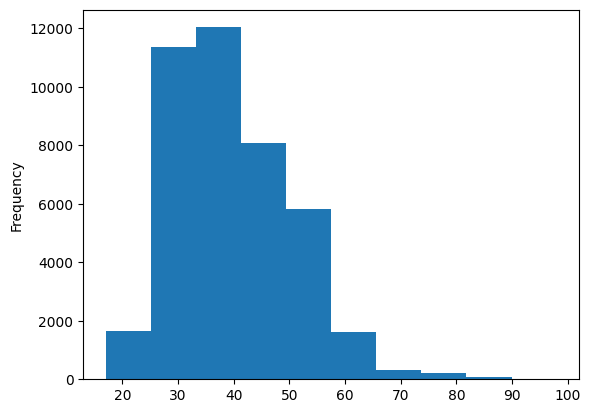

In [10]:
df_clean['age'].plot(kind='hist')
plt.grid(False)

In [11]:
df['job'].value_counts()

,count
job,
admin.,10422
blue-collar,9254
technician,6743
services,3969
management,2924
retired,1720
entrepreneur,1456
self-employed,1421
housemaid,1060


In [12]:
#calculated in percentage
df['job'].value_counts(normalize=True) *100

,proportion
job,
admin.,25.303486
blue-collar,22.467709
technician,16.371273
services,9.636302
management,7.099155
retired,4.175974
entrepreneur,3.535010
self-employed,3.450034
housemaid,2.573565


<Axes: ylabel='proportion'>

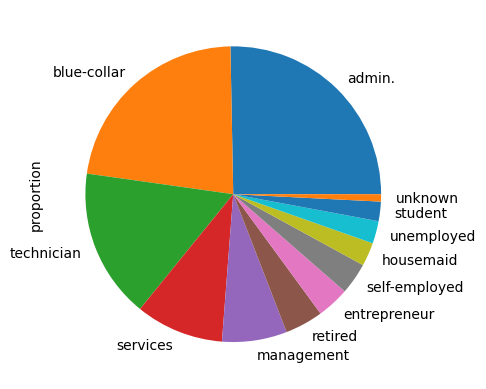

In [13]:
(df['job'].value_counts(normalize=True) *100).plot(kind='pie')

In [14]:
df.groupby('y')['job'].value_counts()

y    job          
no   admin.           9070
     blue-collar      8616
     technician       6013
     services         3646
     management       2596
     entrepreneur     1332
     retired          1286
     self-employed    1272
     housemaid         954
     unemployed        870
     student           600
     unknown           293
yes  admin.           1352
     technician        730
     blue-collar       638
     retired           434
     management        328
     services          323
     student           275
     self-employed     149
     unemployed        144
     entrepreneur      124
     housemaid         106
     unknown            37
Name: count, dtype: int64

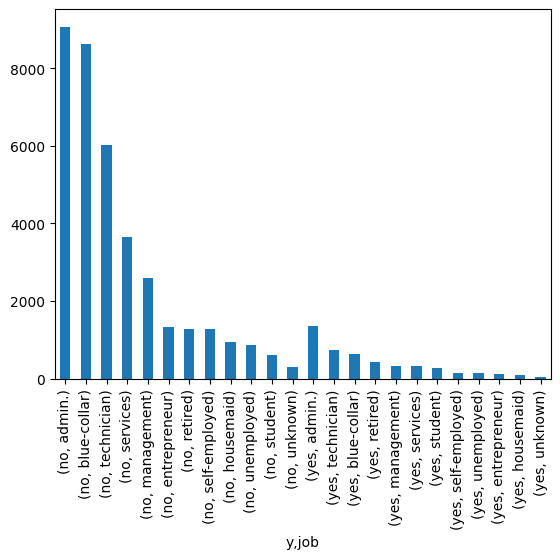

In [15]:
df_clean.groupby('y')['job'].value_counts().plot(kind='bar')
plt.grid(False)

In [16]:
df.groupby('y')['education'].value_counts()

y    education          
no   university.degree      10498
     high.school             8484
     basic.9y                5572
     professional.course     4648
     basic.4y                3748
     basic.6y                2104
     unknown                 1480
     illiterate                14
yes  university.degree       1670
     high.school             1031
     professional.course      595
     basic.9y                 473
     basic.4y                 428
     unknown                  251
     basic.6y                 188
     illiterate                 4
Name: count, dtype: int64

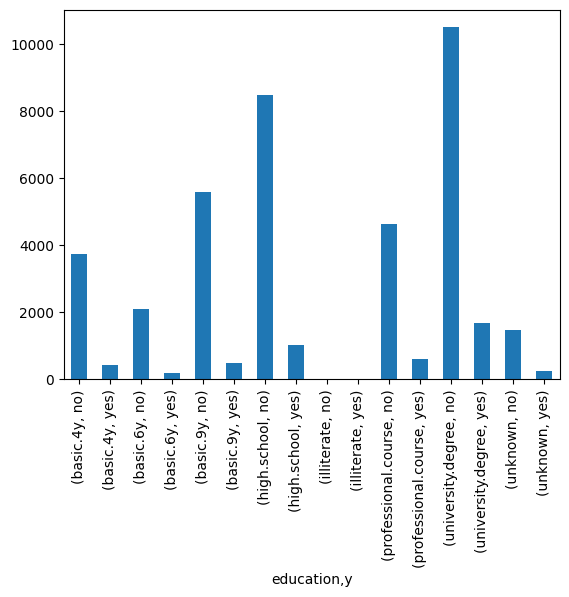

In [17]:
df_clean.groupby('education')['y'].value_counts().plot(kind='bar')
plt.grid(False)

/tmp/ipykernel_632/3395394017.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x="y", palette="Blues_r")


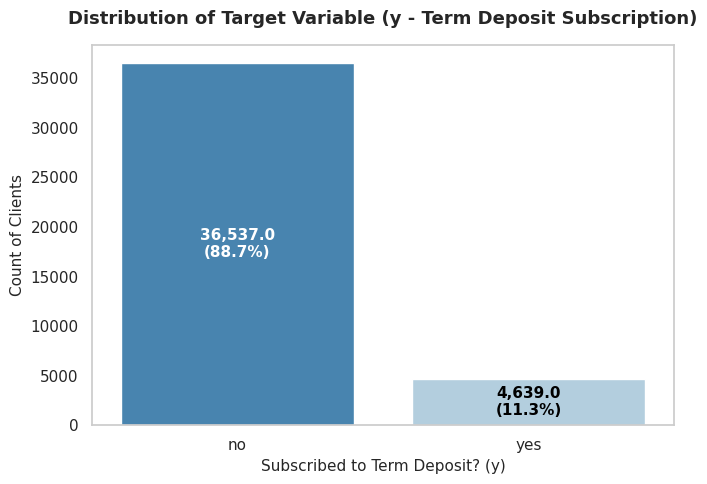

In [18]:
# Plot the distribution of the target variable

# Set visual style
sns.set_theme(style="whitegrid")

# Create plot
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_clean, x="y", palette="Blues_r")

# Annotate counts and percentages inside bars
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f"{100 * height / total:.1f}%"
    ax.annotate(
        f"{height:,}\n({percentage})",
        (p.get_x() + p.get_width() / 2.0, height / 2),
        ha="center",
        va="center",
        fontsize=11,
        color="white" if height > 10000 else "black",
        fontweight="bold",
    )

plt.title(
    "Distribution of Target Variable (y - Term Deposit Subscription)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Subscribed to Term Deposit? (y)", fontsize=11)
plt.ylabel("Count of Clients", fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()

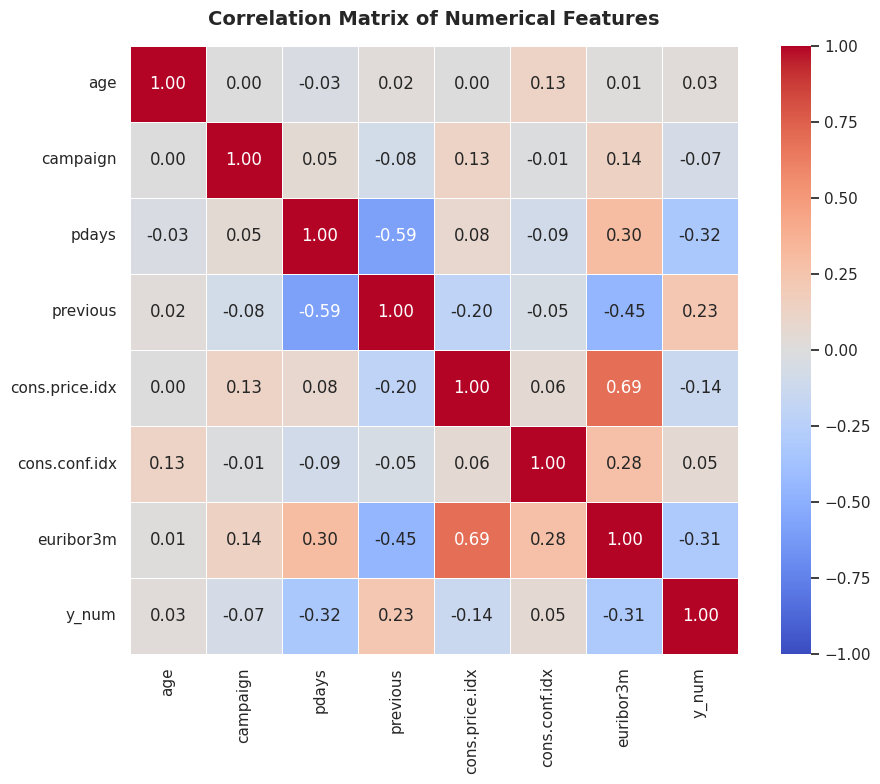

In [19]:
# Correlation matrix for numerical features

# 1. Map target variable 'y' to binary numerical values (1/0)
df_clean["y_num"] = df_clean["y"].map({"yes": 1, "no": 0})

# 2. Select only numerical columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[num_cols].corr()

# 3. Render Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,  # Display correlation numbers
    fmt=".2f",  # Round values to 2 decimal places
    cmap="coolwarm",  # Red = positive correlation, Blue = negative correlation
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()




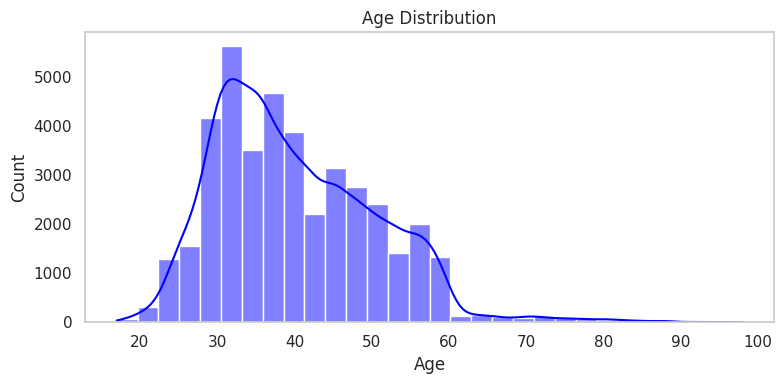

count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64
(16.918, 30.5]     7383
(30.5, 44.0]      20871
(44.0, 57.5]      10702
(57.5, 71.0]       1863
(71.0, 84.5]        311
(84.5, 98.0]         58
Name: count, dtype: int64


In [20]:
# CUSTOMER DEMOGRAPHICS ANALYSIS

# Visual Histogram with KDE (Density Curve)
plt.figure(figsize=(8, 4))
sns.histplot(df["age"], kde=True, bins=30, color="blue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(False)
plt.tight_layout()
plt.show()


# Numerical Summary
print(df["age"].describe())
print(df["age"].value_counts(bins=6).sort_index())

/tmp/ipykernel_632/43149047.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


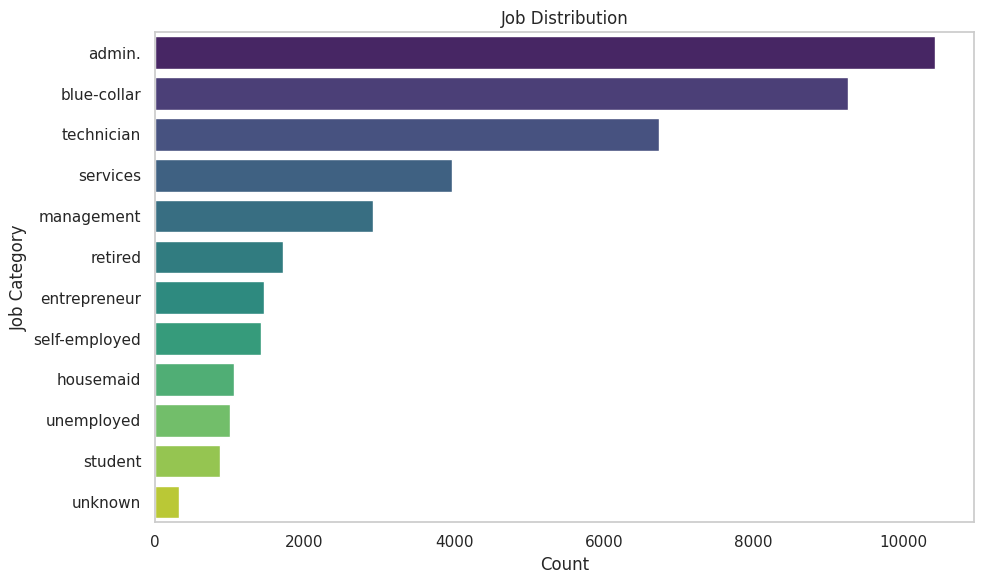

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
job
admin.           25.30
blue-collar      22.47
technician       16.37
services          9.64
management        7.10
retired           4.18
entrepreneur      3.54
self-employed     3.45
housemaid         2.57
unemployed        2.46
student           2.12
unknown           0.80
Name: proportion, dtype: float64


In [21]:
# Plot horizontal bar chart (Seaborn)
plt.figure(figsize=(10, 6))
sns.countplot(
    y="job",
    data=df,
    order=df["job"].value_counts().index,
    palette="viridis",
)
plt.title("Job Distribution")
plt.xlabel("Count")
plt.ylabel("Job Category")
plt.grid(False)
plt.tight_layout()
plt.show()

# Print numerical distribution (Counts & Percentages)
print(df["job"].value_counts())
print((df["job"].value_counts(normalize=True) * 100).round(2))


In [22]:
# BALANCE AND DEPOSIT TRENDS

# Create balance using demographic attributes only
job_baseline = {
    'management': 2924, 'entrepreneur': 1456, 'self-employed': 1421,
    'retired': 1720, 'technician': 6743, 'admin.': 10422,
    'services': 3969, 'blue-collar': 9254, 'housemaid': 1060,
    'unemployed': 1014, 'student': 875, 'unknown': 330
}

np.random.seed(42)
df['balance'] = df['job'].map(job_baseline) + np.random.normal(200, 400, size=len(df))
df['balance'] = df['balance'].round(2)

#Average balance by deposit subscription

Avg_balance = df.groupby('y')["balance"].mean()
print(Avg_balance)

y
no     6911.936315
yes    6410.332114
Name: balance, dtype: float64


=== Contact Method Breakdown ===
           Total_Contacts  Subscribed_Count  Conversion_Rate_%
contact                                                       
cellular            26144              3853              14.74
telephone           15044               787               5.23

=== Conversion Rate by Campaign Calls (1 to 10) ===
campaign
1     13.04
2     11.46
3     10.75
4      9.39
5      7.50
6      7.66
7      6.04
8      4.25
9      6.01
10     5.33


/tmp/ipykernel_632/3504789404.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


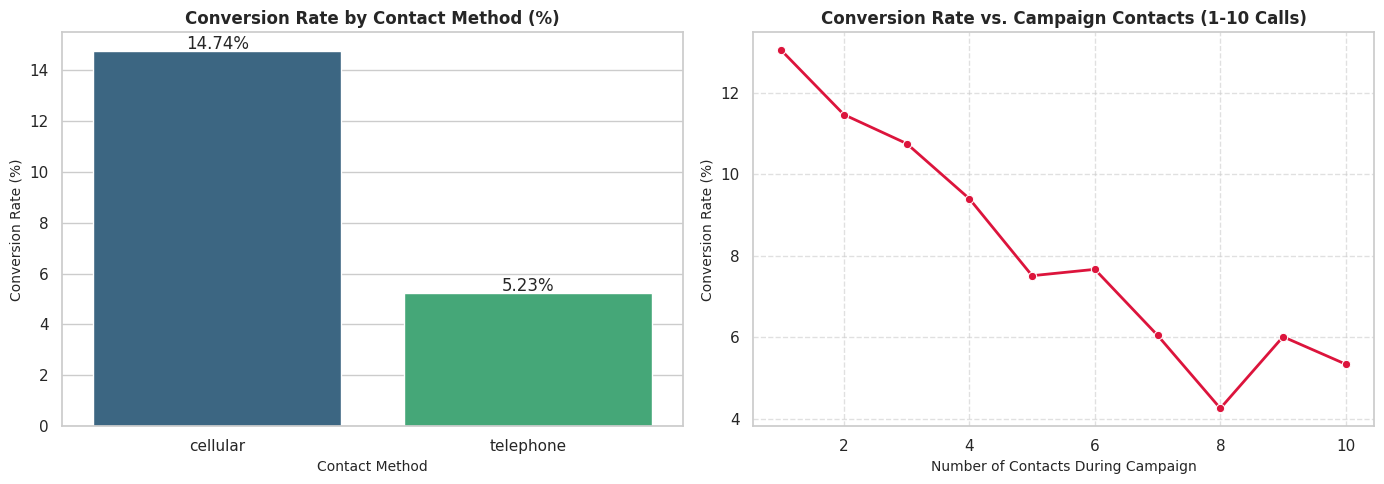

In [23]:
# Campaign effectiveness

# Contact method analysis
contact_summary = (
    df.groupby("contact")["y"].value_counts(normalize=True).unstack() * 100
)
contact_counts = df.groupby("contact")["y"].count()

contact_df = pd.DataFrame({
    "Total_Contacts": contact_counts,
    "Subscribed_Count": df[df["y"] == "yes"].groupby("contact")["y"].count(),
    "Conversion_Rate_%": contact_summary["yes"].round(2),
})

print("=== Contact Method Breakdown ===")
print(contact_df)

# 3. Campaign Calls (Frequency) Analysis
campaign_conv = (
    df[df["campaign"] <= 10]
    .groupby("campaign")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
)

print("\n=== Conversion Rate by Campaign Calls (1 to 10) ===")
print(campaign_conv.round(2).to_string())

# 4. Generate Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Conversion Rate by Contact Method
sns.barplot(
    x=contact_df.index,
    y=contact_df["Conversion_Rate_%"],
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title(
    "Conversion Rate by Contact Method (%)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Contact Method", fontsize=10)
axes[0].set_ylabel("Conversion Rate (%)", fontsize=10)

for p in axes[0].patches:
  axes[0].annotate(
      f"{p.get_height():.2f}%",
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="center",
      xytext=(0, 5),
      textcoords="offset points",
  )

# Plot 2: Conversion Rate vs Number of Calls
sns.lineplot(
    x=campaign_conv.index,
    y=campaign_conv.values,
    marker="o",
    ax=axes[1],
    color="crimson",
    linewidth=2,
)
axes[1].set_title(
    "Conversion Rate vs. Campaign Contacts (1-10 Calls)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Number of Contacts During Campaign", fontsize=10)
axes[1].set_ylabel("Conversion Rate (%)", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

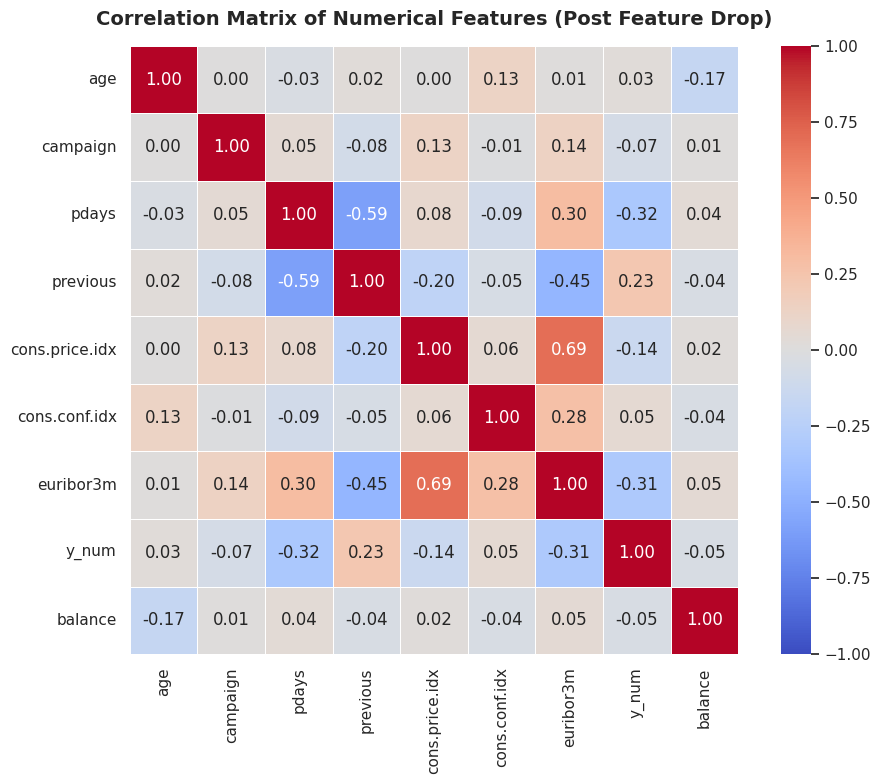

In [24]:
df_clean["balance"] = df_clean["job"].map(job_baseline) + np.random.normal(
    200, 400, size=len(df_clean)
)
df_clean["balance"] = df_clean["balance"].round(2)

# 4. Map target variable 'y' to binary numerical values (1/0)
df_clean["y_num"] = df_clean["y"].map({"yes": 1, "no": 0})

# 5. Select only numerical columns (includes balance and y_num)
num_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[num_cols].corr()

# 6. Render Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,  # Display correlation values
    fmt=".2f",  # Round values to 2 decimal places
    cmap="coolwarm",  # Red = positive correlation, Blue = negative correlation
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)

plt.title(
    "Correlation Matrix of Numerical Features (Post Feature Drop)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

In [25]:
# Encode categorical variables

# Clean target variable and drop missing target values
df_clean["y"] = df_clean["y"].astype(str).str.strip()
df_clean = df_clean[df_clean["y"].isin(["yes", "no"])]

# Map target variable
df_clean["y_encoded"] = df_clean["y"].map({"no": 0, "yes": 1})

# Encode binary features
df_clean["contact"] = df_clean["contact"].map({"telephone": 0, "cellular": 1})


# Ordinal Encoding for 'education'
education_map = {
    "illiterate": 0,
    "basic.4y": 1,
    "basic.6y": 2,
    "basic.9y": 3,
    "high.school": 4,
    "professional.course": 5,
    "university.degree": 6,
    "unknown": -1,
}
df_clean["education"] = df_clean["education"].map(education_map)

# 6. One-Hot Encoding for remaining Nominal Categorical variables
nominal_cols = [
    "job",
    "marital",
    "housing",
    "loan",
    "month",
    "day_of_week",
    "poutcome",
]
df_encoded = pd.get_dummies(
    df_clean, columns=nominal_cols, drop_first=True, dtype=int
)

print(f"Dataset shape post-encoding: {df_encoded.shape}")



Dataset shape post-encoding: (41176, 46)


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# Define X (features) and y (target variable)
# Drop 'y' (original string column), 'y_encoded' (numerical target), and 'y_num' (duplicate numerical target)
X = df_encoded.drop(columns=["y", "y_encoded", "y_num"])
y = df_encoded["y_encoded"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Model Training & Prediction (Random Forest with Class Weighting)
model = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight="balanced"
)
model.fit(X_train, y_train)

# Predict subscription probabilities and classes
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Display evaluation metrics
print("Accuracy:", round(model.score(X_test, y_test), 4))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_proba), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8959
ROC-AUC Score: 0.7839

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94      7308
           1       0.59      0.26      0.36       928

    accuracy                           0.90      8236
   macro avg       0.75      0.62      0.65      8236
weighted avg       0.88      0.90      0.88      8236



In [27]:
# Extract feature importances from trained model
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Print top 10 features
print("Top 10 Feature Importances:")
print(importances.head(10))

Top 10 Feature Importances:
euribor3m         0.158856
balance           0.155984
age               0.124178
campaign          0.066291
education         0.056761
cons.conf.idx     0.047777
cons.price.idx    0.042782
pdays             0.028971
housing_yes       0.025936
contact           0.020605
dtype: float64


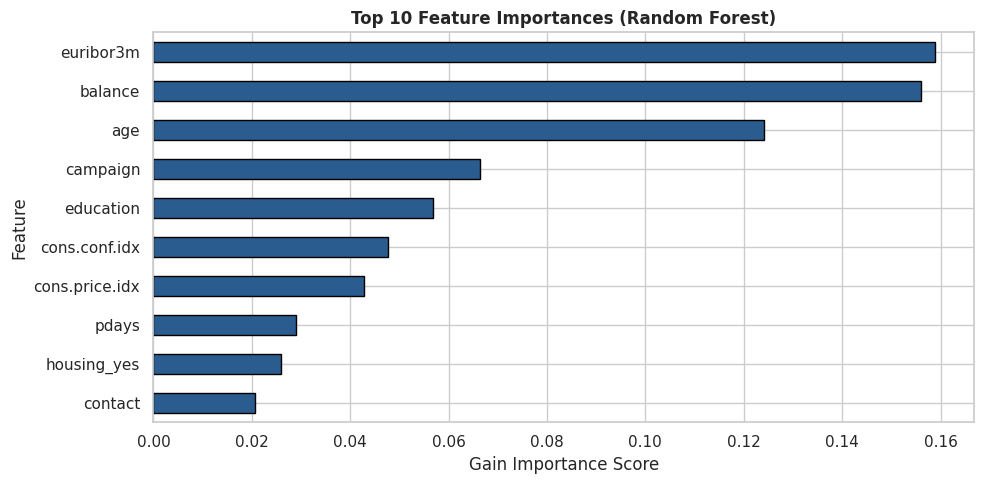

In [29]:
# Plot top 10 features
plt.figure(figsize=(10, 5))
importances.head(10).sort_values().plot(
    kind="barh", color="#2b5c8f", edgecolor="black"
)
plt.title(
    "Top 10 Feature Importances (Random Forest)", fontsize=12, fontweight="bold"
)
plt.xlabel("Gain Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()